In [1]:
import os
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
DATA_DIR = "../data"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
CSV_PATH = os.path.join(DATA_DIR, "train_solution_bounding_boxes.csv")

In [3]:
df = pd.read_csv(CSV_PATH)
df.head()

,image,xmin,ymin,xmax,ymax
0,vid_4_1000.jpg,281.259045,187.035071,327.727931,223.225547
1,vid_4_10000.jpg,15.163531,187.035071,120.329957,236.430180
2,vid_4_10040.jpg,239.192475,176.764801,361.968162,236.430180
3,vid_4_10020.jpg,496.483358,172.363256,630.020260,231.539575
4,vid_4_10060.jpg,16.630970,186.546010,132.558611,238.386422


In [4]:
df["image_path"] = df["image"].apply(lambda x: os.path.join(TRAIN_DIR, x))
df.head()

,image,xmin,ymin,xmax,ymax,image_path
0,vid_4_1000.jpg,281.259045,187.035071,327.727931,223.225547,../data\train\vid_4_1000.jpg
1,vid_4_10000.jpg,15.163531,187.035071,120.329957,236.430180,../data\train\vid_4_10000.jpg
2,vid_4_10040.jpg,239.192475,176.764801,361.968162,236.430180,../data\train\vid_4_10040.jpg
3,vid_4_10020.jpg,496.483358,172.363256,630.020260,231.539575,../data\train\vid_4_10020.jpg
4,vid_4_10060.jpg,16.630970,186.546010,132.558611,238.386422,../data\train\vid_4_10060.jpg


In [5]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

train_df.reset_index(drop=True, inplace=True)
val_df.reset_index(drop=True, inplace=True)

In [6]:
IMG_SIZE = 224

def load_image_bbox(row):
    img = cv2.imread(row.image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    h, w, _ = img.shape
    
    xmin = row.xmin / w
    ymin = row.ymin / h
    xmax = row.xmax / w
    ymax = row.ymax / h
    
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    
    bbox = np.array([xmin, ymin, xmax, ymax])
    
    return img, bbox

In [7]:
img, bbox = load_image_bbox(train_df.iloc[0])

print(img.shape)
print(bbox)

(224, 224, 3)
[0.33719247 0.48962355 0.53183792 0.62347169]


In [8]:
def plot_image_bbox(row):
    img = cv2.imread(row.image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    xmin = int(row.xmin)
    ymin = int(row.ymin)
    xmax = int(row.xmax)
    ymax = int(row.ymax)
    
    cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (255,0,0), 2)
    
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")

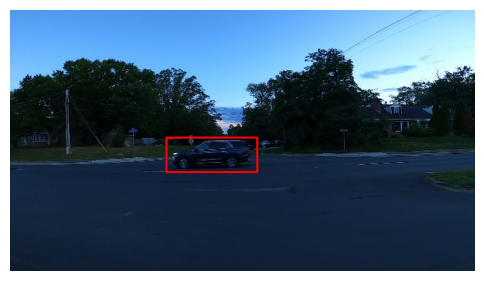

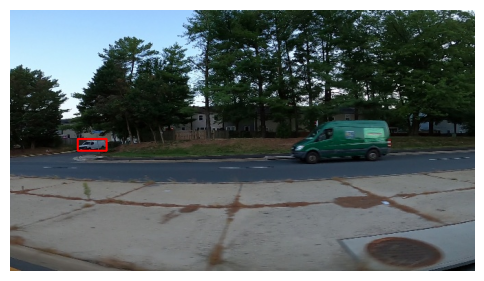

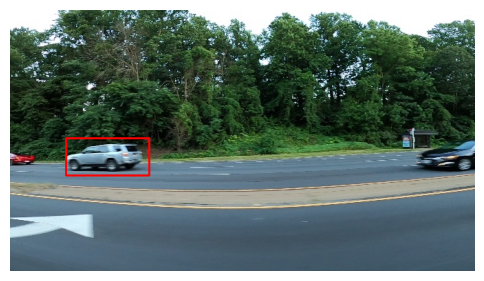

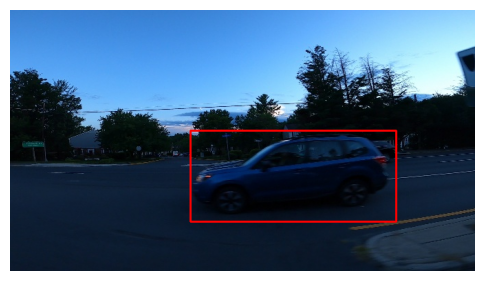

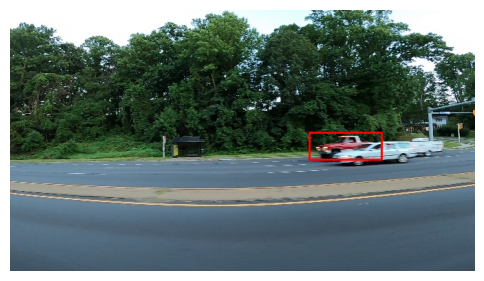

In [9]:
for i in range(5):
    plot_image_bbox(train_df.iloc[i])